<a href="https://colab.research.google.com/github/sumyuck/ML-learning/blob/main/ml/ML_p_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Linear Regression - Gradient Descent Algo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('BostonHousing.csv')

print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


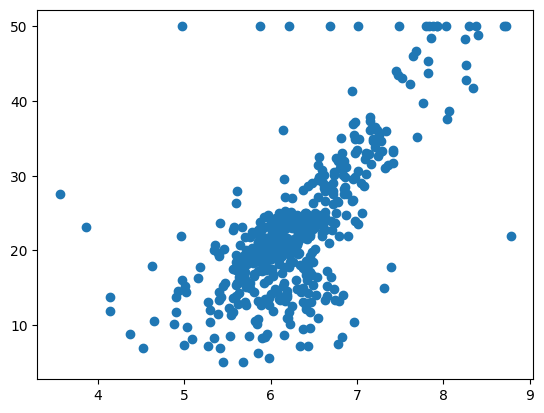

In [ ]:
# Single Variable

x = df['rm'].values
y = df['medv'].values

plt.scatter(x, y)

In [ ]:
w = 0
b = 0
alpha = 0.01
epochs = 1000
m = len(x)

w_history = []
cost_history = []

# Formulas:

**Hypothesis:** h(x) = w * x + b  
**Cost Function:** J(w, b) = (1 / 2m) * Σ (h(x) - y)²  
**Update w:** w = w - α * (1/m) * Σ (h(x) - y) * x  
**Update b:** b = b - α * (1/m) * Σ (h(x) - y)

In [ ]:
for i in range(epochs+1):
    total_error = 0
    dw = 0
    db = 0

    for j in range(m):
        y_pred = w * x[j] + b
        error = y_pred - y[j]
        total_error += error ** 2
        dw += error * x[j]
        db += error

    cost = total_error / (2 * m)
    w = w - alpha * (dw / m)
    b = b - alpha * (db / m)



    w_history.append(w)
    cost_history.append(cost)

    if i % 100 == 0:
        print(f"Epoch {i}: Cost={cost: }, w={w: }, b={b: }")

Epoch 0: Cost= 296.0734584980236, w= 1.4609501501976287, b= 0.225328063241107
Epoch 100: Cost= 29.264923361616944, w= 3.63049736627596, b= 0.13494640910254233
Epoch 200: Cost= 29.08754984893128, w= 3.695895888320226, b=-0.28106130727967993
Epoch 300: Cost= 28.914391051421866, w= 3.7605127454755, b=-0.6920967610589971
Epoch 400: Cost= 28.74534681984011, w= 3.8243572804605392, b=-1.0982193823719646
Epoch 500: Cost= 28.580319384664442, w= 3.8874387243268216, b=-1.499487891026376
Epoch 600: Cost= 28.41921329955395, w= 3.949766197793225, b=-1.8959603049913496
Epoch 700: Cost= 28.261935386145208, w= 4.011348712564761, b=-2.2876939487859396
Epoch 800: Cost= 28.108394680161044, w= 4.072195172635547, b=-2.674745461767483
Epoch 900: Cost= 27.958502378799857, w= 4.132314375576201, b=-3.057170806320871
Epoch 1000: Cost= 27.812171789375146, w= 4.19171501380585, b=-3.4350252759499615



Final Model Parameters:
w = 4.19171501380585
b = -3.4350252759499615


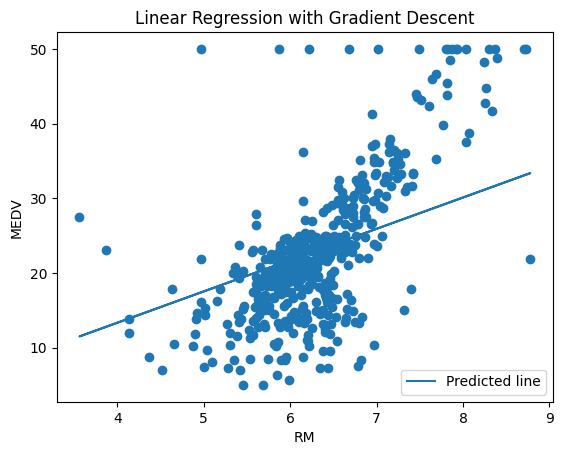

In [ ]:
print("\nFinal Model Parameters:")
print(f"w = {w}")
print(f"b = {b}")

plt.scatter(x, y)
plt.plot(x, w * x + b, label='Predicted line')
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.show()

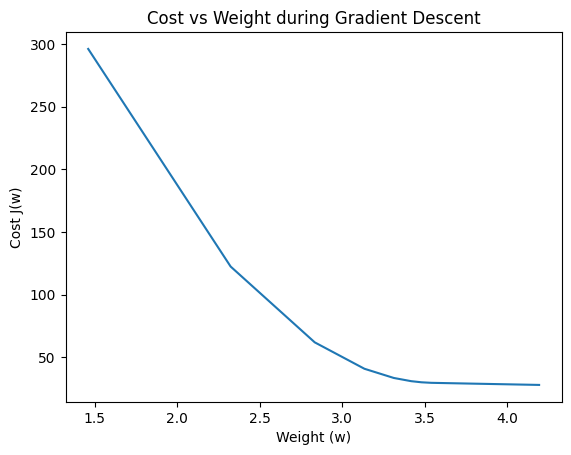

In [ ]:
plt.plot(w_history, cost_history)
plt.xlabel("Weight (w)")
plt.ylabel("Cost J(w)")
plt.title("Cost vs Weight during Gradient Descent")
plt.show()

In [ ]:
# Multiple Variable

df2 = pd.read_csv('BostonHousing.csv')

features = df2.drop(columns=['medv']).values
target = df2['medv'].values

m, n = features.shape

w_multi = np.zeros(n)
b_multi = 0
alpha = 0.01
epochs = 1000

Epoch 0: Cost=126.247238, w=0.058494, b=0.000110, lr=4.88e-06
Epoch 100: Cost=38.405501, w=0.074231, b=0.000580, lr=9.77e-06
Epoch 200: Cost=37.021528, w=0.094373, b=0.001036, lr=4.88e-06
Epoch 300: Cost=36.088293, w=0.114388, b=0.001483, lr=4.88e-06
Epoch 400: Cost=35.382353, w=0.132787, b=0.001918, lr=4.88e-06
Epoch 500: Cost=34.808170, w=0.149726, b=0.002344, lr=9.77e-06
Epoch 600: Cost=34.317474, w=0.165512, b=0.002761, lr=9.77e-06
Epoch 700: Cost=33.883277, w=0.180413, b=0.003172, lr=9.77e-06
Epoch 800: Cost=33.489427, w=0.194632, b=0.003577, lr=9.77e-06
Epoch 900: Cost=33.125833, w=0.208322, b=0.003978, lr=9.77e-06
Epoch 1000: Cost=32.781883, w=0.221476, b=0.004373, lr=4.88e-06

[Multi] Final Parameters:
b = 0.004372589328923286
w shape = (13,)
[Multi] Train MSE = 65.5638
[Multi] R^2 = 0.2234


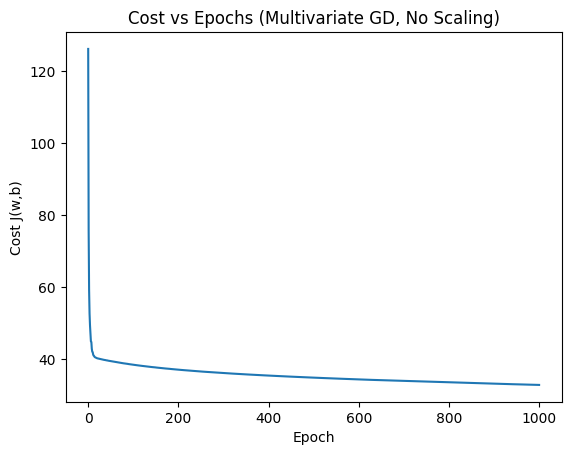

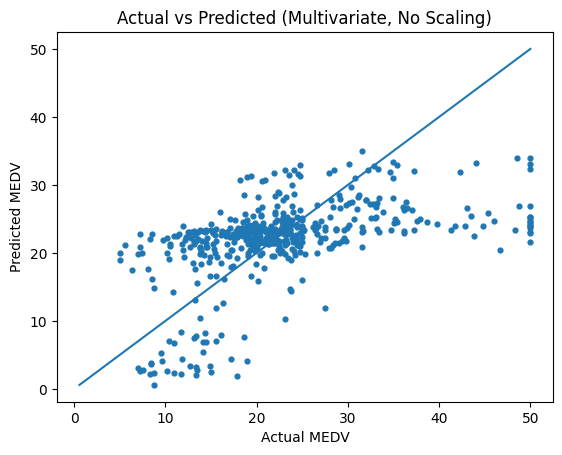

In [ ]:
X = features.astype(np.float64)
y = target.astype(np.float64)

def compute_cost(X, y, w, b):
    e = X @ w + b - y
    return (e @ e) / (2 * len(y))

cost_history_multi = []
lr_history = []

for i in range(epochs + 1):
    preds = X @ w_multi + b_multi
    errors = preds - y
    cost = (errors @ errors) / (2 * m)

    grad_w = (X.T @ errors) / m
    grad_b = errors.mean()

    lr = alpha
    new_w = w_multi - lr * grad_w
    new_b = b_multi - lr * grad_b
    new_cost = compute_cost(X, y, new_w, new_b)

    tries = 0
    while (not np.isfinite(new_cost) or new_cost > cost) and lr > 1e-12 and tries < 50:
        lr *= 0.5
        new_w = w_multi - lr * grad_w
        new_b = b_multi - lr * grad_b
        new_cost = compute_cost(X, y, new_w, new_b)
        tries += 1

    w_multi = new_w
    b_multi = new_b
    cost_history_multi.append(new_cost)
    lr_history.append(lr)

    if i % 100 == 0:
        print(f"Epoch {i}: Cost={new_cost:.6f}, w={np.linalg.norm(w_multi):.6f}, b={b_multi:.6f}, lr={lr:.2e}")

print("\n[Multi] Final Parameters:")
print(f"b = {b_multi}")
print(f"w shape = {w_multi.shape}")

y_pred_all = X @ w_multi + b_multi
mse = np.mean((y_pred_all - y) ** 2)
ss_res = np.sum((y - y_pred_all) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"[Multi] Train MSE = {mse:.4f}")
print(f"[Multi] R^2 = {r2:.4f}")

plt.figure()
plt.plot(range(len(cost_history_multi)), cost_history_multi)
plt.xlabel("Epoch")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs Epochs (Multivariate GD, No Scaling)")
plt.show()

plt.figure()
plt.scatter(y, y_pred_all, s=12)
low = min(y.min(), y_pred_all.min())
high = max(y.max(), y_pred_all.max())
plt.plot([low, high], [low, high])
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted (Multivariate, No Scaling)")
plt.show()

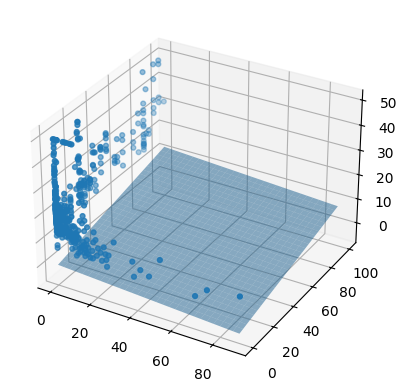

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_3d(X, y, w, b, f1=0, f2=1):
    x1 = X[:, f1]
    x2 = X[:, f2]
    x1g, x2g = np.meshgrid(np.linspace(x1.min(), x1.max(), 30),
                           np.linspace(x2.min(), x2.max(), 30))
    Xg = np.zeros((x1g.size, X.shape[1]))
    Xg[:, f1] = x1g.ravel()
    Xg[:, f2] = x2g.ravel()
    z = (Xg @ w + b).reshape(x1g.shape)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y, s=12)
    ax.plot_surface(x1g, x2g, z, alpha=0.5)
    plt.show()

plot_3d(X, y, w_multi, b_multi, f1=0, f2=1)